In [1]:
# Cell 1：掛載 Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Cell 2：匯入套件
import os
import csv
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


print("1145141515_王小明")


1145141515_王小明


In [3]:
# Cell 3：路徑設定 + 自動下載
import os

NPZ_PATH = "/content/drive/MyDrive/Colab Notebooks/data/printed_chars_dataset.npz"

RESULT_DIR = "/content/drive/MyDrive/Colab Notebooks/results"
os.makedirs(RESULT_DIR, exist_ok=True)

RESULT_TXT = os.path.join(RESULT_DIR, "result_lenet.txt")
RESULT_CSV = os.path.join(RESULT_DIR, "result_lenet.csv")

# 自動下載
if not os.path.exists(NPZ_PATH):
    print("找不到 npz，開始下載...")
    !pip install -q gdown
    import gdown

    file_id = "1OuK9eYrdlXuYl_kbjMy27dW7dgzEnL3_"
    url = f"https://drive.google.com/uc?id={file_id}"

    gdown.download(url, NPZ_PATH, quiet=False)
else:
    print("已找到 npz")

已找到 npz


In [4]:
# Cell 4：讀取資料
data = np.load(NPZ_PATH, allow_pickle=True)

images = data["images"]       # (N, 28, 28)
labels = data["labels"]
label_names = data["label_names"]

print(images.shape, labels.shape)


# Cell 4-2: 資料整理 (數字0跟字母o合併)
# 1. 找出標籤對應的索引 (假設原始 label_names 是 0-9, A-Z)
# 通常 0: '0', 1: '1', 18: 'I', 24: 'O' (請根據你的 label_names 實際順序核對)
idx_0 = np.where(label_names == '0')[0][0]
idx_O = np.where(label_names == 'O')[0][0]
idx_1 = np.where(label_names == '1')[0][0]
idx_I = np.where(label_names == 'I')[0][0]
print(f"合併前標籤索引: 0:{idx_0}, O:{idx_O}, 1:{idx_1}, I:{idx_I}")
# 2. 執行合併：將 O 的標籤改為 0，將 I 的標籤改為 1
labels[labels == idx_O] = idx_0
labels[labels == idx_I] = idx_1

# 3. 移除被合併的名稱，更新 label_names (數量變為 34)
# 這裡使用 list comprehension 移除 'O' 和 'I'
new_label_names = np.array([name for name in label_names if name not in ['O', 'I']])

# 4. 重新編碼標籤 (Re-indexing)
# 因為移除 O 和 I 後，後面的標籤索引會斷開，我們需要將它們補齊為 0~33
old_to_new_map = {old_idx: i for i, old_idx in enumerate([i for i in range(36) if i not in [idx_O, idx_I]])}

# 將原始 labels 陣列中的舊索引替換為新索引
new_labels = np.array([old_to_new_map[l] for l in labels])

# 更新全域變數
labels = new_labels
label_names = new_label_names
labels_num = len(label_names)

print(f"合併後 labels 唯一值數量: {len(np.unique(labels))}")
print(f"新的 label_names 總數: {len(label_names)}")
print(f"新標籤清單: {label_names}")

(1800, 28, 28) (1800,)
合併前標籤索引: 0:0, O:24, 1:1, I:18
合併後 labels 唯一值數量: 34
新的 label_names 總數: 34
新標籤清單: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' 'A' 'B' 'C' 'D' 'E' 'F' 'G' 'H'
 'J' 'K' 'L' 'M' 'N' 'P' 'Q' 'R' 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']


In [5]:
# Cell 5：前處理（轉 PyTorch 格式）
# 正規化 + 增加 channel 維度
X = images.astype(np.float32) / 255.0
X = np.expand_dims(X, axis=1)   # (N, 1, 28, 28)

y = labels

In [6]:
# Cell 6：切 train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(1440, 1, 28, 28) (360, 1, 28, 28)


In [7]:
# Cell 6-2：可以針對train部分進行資料擴增
#
#
#

In [8]:
# Cell 7：轉成 Tensor
X_train = torch.tensor(X_train)
X_test = torch.tensor(X_test)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [9]:
# Cell 8：建立 LeNet
###############
#  可針對此區更改模型架構
###############
class LeNet(nn.Module):
    def __init__(self, num_classes=labels_num):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5),   # 28 -> 24
            nn.ReLU(),
            nn.MaxPool2d(2),                  # 24 -> 12

            nn.Conv2d(6, 16, kernel_size=5),  # 12 -> 8
            nn.ReLU(),
            nn.MaxPool2d(2)                   # 8 -> 4
        )

        self.fc = nn.Sequential(
            nn.Linear(16*4*4, 120),
            nn.ReLU(),
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [10]:
# Cell 9：設定 device
device_gpu = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device_cpu = torch.device("cpu")

print("GPU available:", torch.cuda.is_available())

GPU available: False


In [18]:
# Cell 10：訓練模型（用 GPU）
model = LeNet().to(device_gpu)

# 顯示模型大小
total_params = sum(p.numel() for p in model.parameters())
print(f"模型總參數數量: {total_params}")

###########################
# 可嘗試優化此區塊
criterion = nn.CrossEntropyLoss() # 多分類問題多採用交叉熵
optimizer = optim.SGD(model.parameters(), lr=0.01)
#optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

EPOCHS = 5
BATCH_SIZE = 64
#
############################
train_start = time.perf_counter()

for epoch in range(EPOCHS):
    perm = torch.randperm(len(X_train))

    for i in range(0, len(X_train), BATCH_SIZE):
        idx = perm[i:i+BATCH_SIZE]

        xb = X_train[idx].to(device_gpu)
        yb = y_train[idx].to(device_gpu)

        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}, Loss={loss.item():.4f}")

train_end = time.perf_counter()
train_time = train_end - train_start

print(f"訓練時間: {train_time:.4f} 秒")

模型總參數數量: 46466
Epoch 1, Loss=3.4755
Epoch 2, Loss=2.7145
Epoch 3, Loss=1.7645
Epoch 4, Loss=0.9795
Epoch 5, Loss=0.6498
訓練時間: 3.1537 秒


In [19]:
# Cell 11：推論函式
def inference(model, X, device):
    model.eval()
    preds = []

    with torch.no_grad():
        for i in range(0, len(X), 128):
            xb = X[i:i+128].to(device)
            out = model(xb)
            pred = torch.argmax(out, dim=1)
            preds.append(pred.cpu().numpy())

    return np.concatenate(preds)

In [20]:
# Cell 12：GPU 推論時間
start = time.perf_counter()
y_pred_gpu = inference(model, X_test, device_gpu)
end = time.perf_counter()

gpu_time = end - start
gpu_avg = gpu_time / len(X_test) * 1000

gpu_acc = accuracy_score(y_test.numpy(), y_pred_gpu)

print("GPU ACC:", gpu_acc)
print("GPU time:", gpu_time)

GPU ACC: 0.8222222222222222
GPU time: 0.07970020099992325


In [14]:
# Cell 14：顯示結果
print("\n=== LeNet 結果 ===")
print(f"Train time: {train_time:.4f} sec")

print(f"ACC: {gpu_acc:.4f}")
print(f"total time: {gpu_time:.4f} sec")
print(f"avg: {gpu_avg:.4f} ms")


=== LeNet 結果 ===
Train time: 5.3567 sec
ACC: 0.0278
total time: 0.0599 sec
avg: 0.1664 ms


In [15]:
# Cell 15（新增）：分類報告
from sklearn.metrics import classification_report

print("\n=== Classification Report (GPU) ===")
report_gpu = classification_report(
    y_test.numpy(),
    y_pred_gpu,
    target_names=label_names,
    digits=4
)
print(report_gpu)


=== Classification Report (GPU) ===
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        20
           1     0.0000    0.0000    0.0000        20
           2     0.0000    0.0000    0.0000        10
           3     0.0000    0.0000    0.0000        10
           4     0.0000    0.0000    0.0000        10
           5     0.0000    0.0000    0.0000        10
           6     0.0000    0.0000    0.0000        10
           7     0.0000    0.0000    0.0000        10
           8     0.0000    0.0000    0.0000        10
           9     0.0000    0.0000    0.0000        10
           A     0.0000    0.0000    0.0000        10
           B     0.0000    0.0000    0.0000        10
           C     0.0000    0.0000    0.0000        10
           D     0.0000    0.0000    0.0000        10
           E     0.0000    0.0000    0.0000        10
           F     0.0000    0.0000    0.0000        10
           G     0.0000    0.0000    0.0000 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


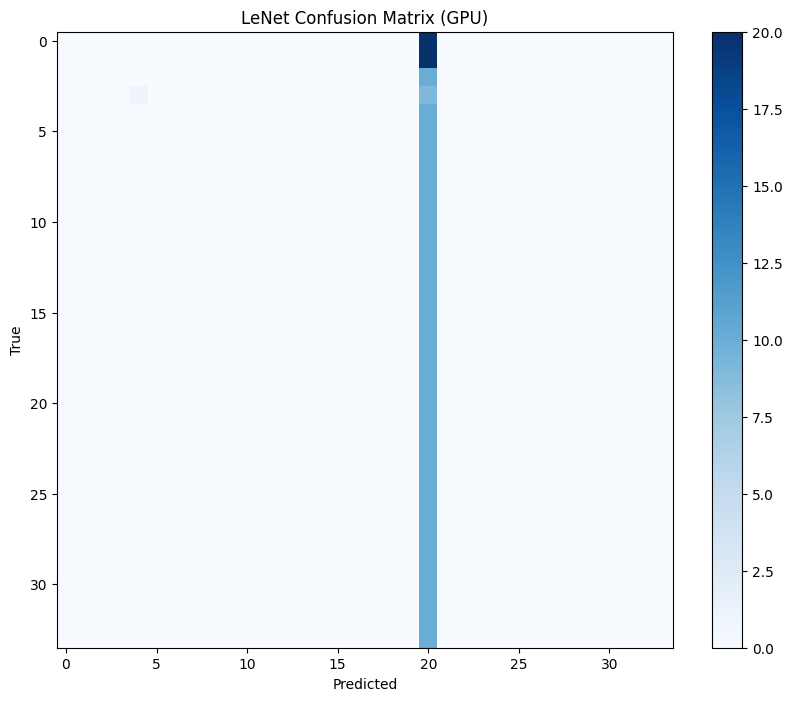

In [16]:
# Cell 16（新增）：混淆矩陣（GPU）
from sklearn.metrics import confusion_matrix

cm_gpu = confusion_matrix(y_test.numpy(), y_pred_gpu)

plt.figure(figsize=(10, 8))
plt.imshow(cm_gpu, cmap="Blues")
plt.title("LeNet Confusion Matrix (GPU)")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

錯誤數量： 350


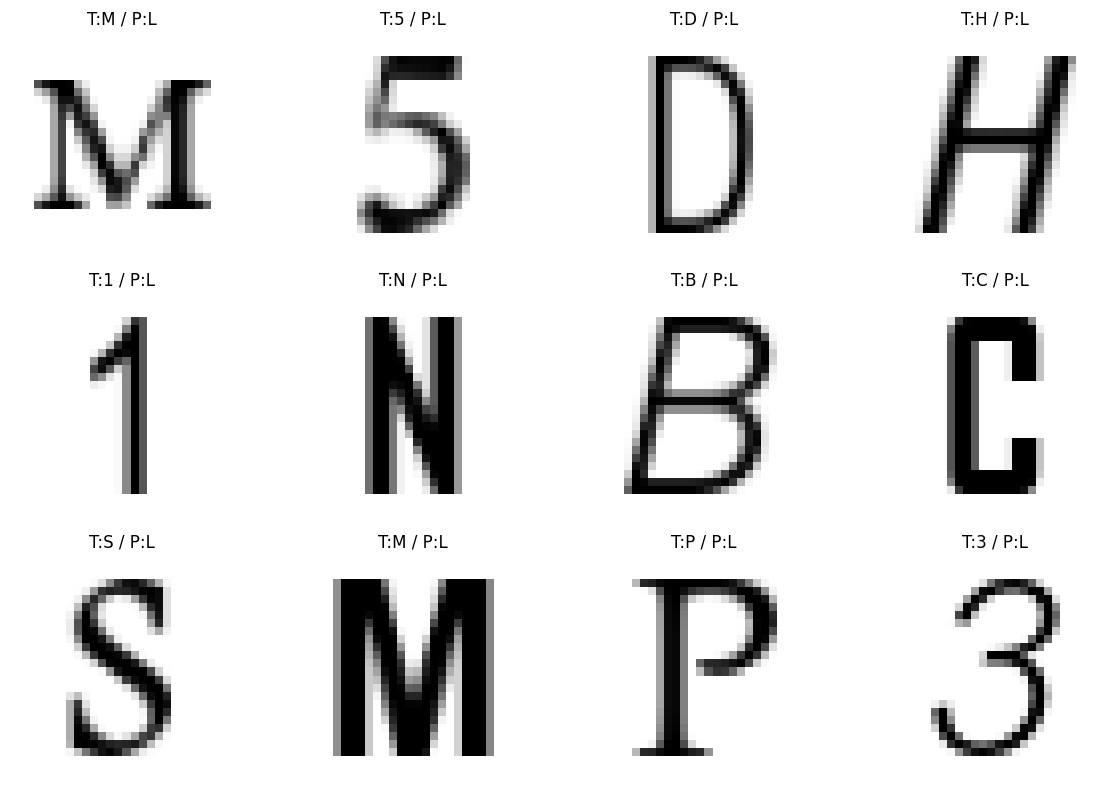

In [17]:
# Cell 17: 找錯誤案例
wrong_idx = np.where(y_pred_gpu != y_test.numpy())[0]

print("錯誤數量：", len(wrong_idx))

plt.figure(figsize=(12, 8))

for i in range(min(12, len(wrong_idx))):
    idx = wrong_idx[i]

    img = X_test[idx].cpu().numpy().reshape(28, 28)
    true_label = label_names[y_test[idx]]
    pred_label = label_names[y_pred_gpu[idx]]

    plt.subplot(3, 4, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"T:{true_label} / P:{pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()